# MMCR / Fakeddit — 6-Way Text Classification

All models, plots, logs, predictions, and image samples are saved into a single Drive folder:
`/content/drive/MyDrive/MMCR_Fakeddit_Results/`.

**Pipeline**: Load → Cap≤10k → Tokenize → Train (TextCNN, BiLSTM, CNN+BiLSTM) → Pick best by VALID F1 → Plot & Save → Predict Test + Confidence → Image Panels.

## 🔧 Setup: Mount Drive & Create Results Folders

In [ ]:

from google.colab import drive
import os

# Mount Drive
drive.mount('/content/drive', force_remount=False)

# Base results directory
BASE_DIR = "/content/drive/MyDrive/MMCR_Model_Final"
os.makedirs(BASE_DIR, exist_ok=True)

# Subfolders
SUBDIRS = ["models", "plots", "predictions", "samples", "logs"]
for sub in SUBDIRS:
    os.makedirs(os.path.join(BASE_DIR, sub), exist_ok=True)

print("✅ All outputs will be stored under:", BASE_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ All outputs will be stored under: /content/drive/MyDrive/MMCR_Model_Final


## Imports

In [ ]:

import os, io, re, json, hashlib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

import tensorflow as tf
from tensorflow.keras import layers, Model, Input, regularizers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, precision_recall_fscore_support
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
print("TensorFlow:", tf.__version__)


TensorFlow: 2.19.0


## Configuration & Helpers

In [ ]:

SEED        = 42
MAX_VOCAB   = 50_000
MAX_LEN     = 128
NUM_CLASSES = 6

TEXT_COL   = "clean_title"
LABEL_COL  = "6_way_label"
IMAGE_COL  = "image_url"   # optional

TRAIN_PATH = "/mnt/data/all_train.tsv"
VALID_PATH = "/mnt/data/all_validate.tsv"
TEST_PATH  = "/mnt/data/all_test_public.tsv"

np.random.seed(SEED)
tf.random.set_seed(SEED)

def stratified_cap(df, label_col=LABEL_COL, n_max=10_000, seed=SEED):
    df = df.dropna(subset=[label_col]).copy()
    if len(df) <= n_max:
        return df.sample(frac=1, random_state=seed).reset_index(drop=True)
    counts = df[label_col].value_counts()
    frac = n_max / len(df)
    take_per_class = (counts * frac).round().clip(lower=1).astype(int)
    delta = int(take_per_class.sum() - n_max)
    if delta > 0:
        for cls in take_per_class.sort_values(ascending=False).index:
            if delta == 0: break
            if take_per_class[cls] > 1:
                take_per_class[cls] -= 1
                delta -= 1
    parts = [df[df[label_col]==cls].sample(n=int(k), random_state=seed) for cls,k in take_per_class.items()]
    return pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)

def load_any(path):
    if path.endswith(".tsv"):
        return pd.read_csv(path, sep="\t")
    return pd.read_csv(path)

def savefig(path):
    plt.tight_layout()
    plt.savefig(path, dpi=150)
    print("Saved plot:", path)

def plot_history(hist, name="Model"):
    # Accuracy
    plt.figure()
    plt.plot(hist.get("accuracy", []), label="train")
    plt.plot(hist.get("val_accuracy", []), label="val")
    plt.title(f"{name} Accuracy"); plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend()
    savefig(os.path.join(BASE_DIR, "plots", f"{name}_accuracy.png"))
    plt.show()

    # Loss
    plt.figure()
    plt.plot(hist.get("loss", []), label="train")
    plt.plot(hist.get("val_loss", []), label="val")
    plt.title(f"{name} Loss"); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()
    savefig(os.path.join(BASE_DIR, "plots", f"{name}_loss.png"))
    plt.show()

def plot_confusion_and_perclass(y_true, y_pred, name="VALID", prefix="best_model"):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
    plt.figure()
    plt.imshow(cm, interpolation="nearest")
    plt.title(f"Confusion Matrix ({name})"); plt.colorbar()
    ticks = np.arange(NUM_CLASSES)
    plt.xticks(ticks, ticks); plt.yticks(ticks, ticks)
    plt.xlabel("Predicted"); plt.ylabel("True")
    savefig(os.path.join(BASE_DIR, "plots", f"{prefix}_cm_{name}.png"))
    plt.show()

    _, _, f1_per_class, _ = precision_recall_fscore_support(y_true, y_pred, labels=list(range(NUM_CLASSES)))
    plt.figure()
    plt.bar(np.arange(NUM_CLASSES), f1_per_class)
    plt.title(f"Per-class F1 ({name})"); plt.xlabel("Class id"); plt.ylabel("F1")
    savefig(os.path.join(BASE_DIR, "plots", f"{prefix}_perclassF1_{name}.png"))
    plt.show()


## Label Mapping & Tokenizer (Train-only)

In [ ]:
# Cell 2 — Preprocessing
# Make sure constants/paths are defined above this cell: TRAIN_PATH, VALID_PATH, TEST_PATH, LABEL_COL, TEXT_COL, MAX_VOCAB, MAX_LEN, SEED

train_df = load_any(TRAIN_PATH)
valid_df = load_any(VALID_PATH)
test_df  = load_any(TEST_PATH)

train_df = stratified_cap(train_df, LABEL_COL, 800_000, SEED)
valid_df = stratified_cap(valid_df, LABEL_COL, 500_000, SEED)
if LABEL_COL in test_df.columns:
    test_df = stratified_cap(test_df, LABEL_COL, 500_000, SEED)
else:
    test_df = test_df.sample(n=min(500_000, len(test_df)), random_state=SEED).reset_index(drop=True)

print("Shapes (raw):", train_df.shape, valid_df.shape, test_df.shape)
display(train_df.head(2))

# label mapping
label_map = {lbl:i for i,lbl in enumerate(sorted(train_df[LABEL_COL].dropna().unique()))}
inv_label_map = {v:k for k,v in label_map.items()}

for df in (train_df, valid_df, test_df):
    if LABEL_COL in df.columns:
        if df[LABEL_COL].dtype.kind in "iu":
            df[LABEL_COL] = df[LABEL_COL].astype(int)
        else:
            df[LABEL_COL] = df[LABEL_COL].map(label_map)

# tokenization + padding
tok = Tokenizer(num_words=MAX_VOCAB, oov_token="<unk>")
tok.fit_on_texts(train_df[TEXT_COL].astype(str))

def to_seq(df):
    return pad_sequences(tok.texts_to_sequences(df[TEXT_COL].astype(str)),
                         maxlen=MAX_LEN, padding="post", truncating="post")

Xtr = to_seq(train_df)
Xva = to_seq(valid_df)
Xte = to_seq(test_df)

y_train_int = train_df[LABEL_COL].values
y_valid_int = valid_df[LABEL_COL].values
y_test_int  = test_df[LABEL_COL].values if LABEL_COL in test_df.columns else None


y_train = tf.keras.utils.to_categorical(y_train_int, NUM_CLASSES)
y_valid = tf.keras.utils.to_categorical(y_valid_int, NUM_CLASSES)
y_test  = tf.keras.utils.to_categorical(y_test_int, NUM_CLASSES) if y_test_int is not None else None

vocab_size = min(MAX_VOCAB, len(tok.word_index) + 1)

print("Final shapes:", Xtr.shape, Xva.shape, Xte.shape)


Shapes (raw): (800000, 20) (92444, 20) (92444, 20)


,Unnamed: 0.2,Unnamed: 0,Unnamed: 0.1,Unnamed: 0.1.1,author,clean_title,created_utc,domain,hasImage,id,image_url,linked_submission_id,num_comments,score,subreddit,title,upvote_ratio,2_way_label,3_way_label,6_way_label
0,475290,475290,NaN,NaN,AsMyLastEmailStated,the way these vines perfectly cover the front ...,1.554165e+09,i.redd.it,True,b8bvz4,https://preview.redd.it/5okggygiwqp21.jpg?widt...,NaN,1.0,43,mildlyinteresting,The way these vines perfectly cover the front ...,0.89,1,0,0
1,542440,542440,NaN,NaN,esteeb_,dude chilling park,1.403044e+09,i.imgur.com,True,28eqwz,https://external-preview.redd.it/-gdePE_Pl14ro...,NaN,3.0,2,photoshopbattles,Dude Chilling Park [x-post from /r/pics],0.57,1,0,0


Final shapes: (800000, 128) (92444, 128) (92444, 128)


In [ ]:
# Cell 1 — imports + your model builders
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from collections import Counter
from tensorflow.keras import layers, regularizers, Input, Model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import accuracy_score, f1_score

# Your model builder functions (paste exactly as you provided)
def build_textcnn(vocab_size, embed_dim=128, max_len=MAX_LEN, num_classes=NUM_CLASSES):
    inp = Input(shape=(max_len,), dtype="int32")
    emb = layers.Embedding(vocab_size, embed_dim)(inp)
    emb = layers.Dropout(0.3)(emb)
    pooled = []
    for k in [3,4,5]:
        c = layers.Conv1D(128, k, activation="relu", padding="valid",
                          kernel_regularizer=regularizers.l2(1e-4))(emb)
        c = layers.GlobalMaxPooling1D()(c)
        pooled.append(c)
    x = layers.Concatenate()(pooled)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)
    return Model(inp, out)

def build_bilstm(vocab_size, embed_dim=128, max_len=MAX_LEN, num_classes=NUM_CLASSES):
    inp = Input(shape=(max_len,))
    emb = layers.Embedding(vocab_size, embed_dim)(inp)
    emb = layers.Dropout(0.3)(emb)
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True, dropout=0.3))(emb)
    x = layers.GlobalMaxPooling1D()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)
    return Model(inp, out)

def build_cnn_bilstm(vocab_size, embed_dim=128, max_len=MAX_LEN, num_classes=NUM_CLASSES):
    inp = Input(shape=(max_len,))
    emb = layers.Embedding(vocab_size, embed_dim)(inp)
    emb = layers.Dropout(0.3)(emb)
    c = layers.Conv1D(128, 3, activation="relu", padding="same", kernel_regularizer=regularizers.l2(1e-4))(emb)
    c = layers.MaxPooling1D(2)(c)
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True, dropout=0.3))(c)
    x = layers.GlobalMaxPooling1D()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation="relu",kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)
    return Model(inp, out)

print("Builders loaded.")


Builders loaded.


## Define Models (TextCNN, BiLSTM, CNN+BiLSTM)

In [ ]:
# Cell 3 — shared setup (using final_results.csv)


os.makedirs(os.path.join(BASE_DIR, "models"), exist_ok=True)
os.makedirs(os.path.join(BASE_DIR, "logs"), exist_ok=True)
os.makedirs(os.path.join(BASE_DIR, "checkpoints"), exist_ok=True)

# class weights
cnt = Counter(y_train_int)
total = sum(cnt.values())
class_weight = {c: total / (NUM_CLASSES * cnt[c]) for c in cnt}

# containers for this kernel session
results = []
histories = {}
paths = {}

# helper eval
def eval_split(model, X, y):
    proba = model.predict(X, batch_size=256, verbose=0)
    pred = proba.argmax(axis=1)
    return accuracy_score(y, pred), f1_score(y, pred, average="macro")

# final results CSV path (note .csv extension)
final_results = os.path.join(BASE_DIR, "logs", "new_final_results.csv")
prev_df = pd.read_csv(final_results) if os.path.exists(final_results) else pd.DataFrame()
print("Shared setup done. Previous results rows:", len(prev_df))


Shared setup done. Previous results rows: 0


In [ ]:
# Cell 4 — Train TextCNN
name = "TextCNN"
m = build_textcnn(vocab_size)

loss_fn = tf.keras.losses.CategoricalCrossentropy(
    label_smoothing=0.1
)
optimizer = tf.keras.optimizers.Adam(learning_rate=2e-4)
m.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=["accuracy"]
)

ckpt_dir = os.path.join(BASE_DIR, "checkpoints")
os.makedirs(ckpt_dir, exist_ok=True)

ckpt_path = os.path.join(ckpt_dir, f"best_{name}.h5")                      # full model
weights_path = os.path.join(ckpt_dir, f"best_weights_{name}.weights.h5")  # weights only

cb = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True, verbose=1),

    # save full model
    tf.keras.callbacks.ModelCheckpoint(
        filepath=ckpt_path, monitor="val_loss",
        save_best_only=True, save_weights_only=False, verbose=1
    ),

    # save weights only
    tf.keras.callbacks.ModelCheckpoint(
        filepath=weights_path, monitor="val_loss",
        save_best_only=True, save_weights_only=True, verbose=0
    ),

    tf.keras.callbacks.CSVLogger(os.path.join(BASE_DIR, "logs", f"train_log_{name}.csv"), append=True)
]

print(f"\n===== Training {name} =====")
hist = m.fit(
    Xtr, y_train,
    validation_data=(Xva, y_valid),
    epochs=25, batch_size=256,
    class_weight=class_weight,
    callbacks=cb, verbose=1
)

histories[name] = hist.history

# Evaluation
tr_acc, tr_f1 = eval_split(m, Xtr, y_train_int)
va_acc, va_f1 = eval_split(m, Xva, y_valid_int)
te_acc, te_f1 = (np.nan, np.nan) if y_test_int is None else eval_split(m, Xte, y_test_int)

# Save final model
model_path = os.path.join(BASE_DIR, "models", f"best_{name}.h5")
os.makedirs(os.path.join(BASE_DIR, "models"), exist_ok=True)
m.save(model_path)
paths[name] = model_path

results.append({
    "model": name,
    "train_acc": tr_acc, "train_f1": tr_f1,
    "valid_acc": va_acc, "valid_f1": va_f1,
    "test_acc": te_acc,  "test_f1": te_f1,
    "model_path": model_path
})

results_df = pd.DataFrame(results)
# 'prev_df' was loaded from final_results.csv in the shared setup cell
if "prev_df" in globals() and not prev_df.empty:
    out_df = pd.concat([prev_df, results_df], ignore_index=True)
else:
    out_df = results_df

# final_results variable points to the CSV path (final_results.csv)
out_df.to_csv(final_results, index=False)
print("Saved model results to:", final_results)
display(out_df.tail(3).reset_index(drop=True))



===== Training TextCNN =====
Epoch 1/25
3121/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4026 - loss: 1.5694
Epoch 1: val_loss improved from inf to 1.21322, saving model to /content/drive/MyDrive/MMCR_Model_Final/checkpoints/best_TextCNN.h5


3125/3125 ━━━━━━━━━━━━━━━━━━━━ 26s 6ms/step - accuracy: 0.4028 - loss: 1.5692 - val_accuracy: 0.6417 - val_loss: 1.2132 - learning_rate: 2.0000e-04
Epoch 2/25
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6384 - loss: 1.1906
Epoch 2: val_loss improved from 1.21322 to 1.12711, saving model to /content/drive/MyDrive/MMCR_Model_Final/checkpoints/best_TextCNN.h5


3125/3125 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.6384 - loss: 1.1906 - val_accuracy: 0.6797 - val_loss: 1.1271 - learning_rate: 2.0000e-04
Epoch 3/25
3123/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6766 - loss: 1.1018
Epoch 3: val_loss improved from 1.12711 to 1.08037, saving model to /content/drive/MyDrive/MMCR_Model_Final/checkpoints/best_TextCNN.h5


3125/3125 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - accuracy: 0.6766 - loss: 1.1017 - val_accuracy: 0.6986 - val_loss: 1.0804 - learning_rate: 2.0000e-04
Epoch 4/25
3120/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6972 - loss: 1.0492
Epoch 4: val_loss improved from 1.08037 to 1.05831, saving model to /content/drive/MyDrive/MMCR_Model_Final/checkpoints/best_TextCNN.h5


3125/3125 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.6972 - loss: 1.0492 - val_accuracy: 0.7072 - val_loss: 1.0583 - learning_rate: 2.0000e-04
Epoch 5/25
3122/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7110 - loss: 1.0089
Epoch 5: val_loss improved from 1.05831 to 1.04929, saving model to /content/drive/MyDrive/MMCR_Model_Final/checkpoints/best_TextCNN.h5


...

3125/3125 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.7814 - loss: 0.8370 - val_accuracy: 0.7305 - val_loss: 1.0181 - learning_rate: 1.0000e-04
Epoch 17/25
3122/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7839 - loss: 0.8310
Epoch 17: val_loss did not improve from 1.01807
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - accuracy: 0.7839 - loss: 0.8310 - val_accuracy: 0.7290 - val_loss: 1.0204 - learning_rate: 1.0000e-04
Epoch 18/25
3117/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7862 - loss: 0.8265
Epoch 18: val_loss improved from 1.01807 to 1.01514, saving model to /content/drive/MyDrive/MMCR_Model_Final/checkpoints/best_TextCNN.h5


3125/3125 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.7863 - loss: 0.8265 - val_accuracy: 0.7328 - val_loss: 1.0151 - learning_rate: 1.0000e-04
Epoch 19/25
3118/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7881 - loss: 0.8228
Epoch 19: val_loss improved from 1.01514 to 1.01175, saving model to /content/drive/MyDrive/MMCR_Model_Final/checkpoints/best_TextCNN.h5


3125/3125 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.7881 - loss: 0.8228 - val_accuracy: 0.7348 - val_loss: 1.0117 - learning_rate: 1.0000e-04
Epoch 20/25
3122/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7909 - loss: 0.8180
Epoch 20: val_loss did not improve from 1.01175
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - accuracy: 0.7909 - loss: 0.8180 - val_accuracy: 0.7338 - val_loss: 1.0135 - learning_rate: 1.0000e-04
Epoch 21/25
3120/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7918 - loss: 0.8160
Epoch 21: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 21: val_loss did not improve from 1.01175
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - accuracy: 0.7918 - loss: 0.8160 - val_accuracy: 0.7310 - val_loss: 1.0177 - learning_rate: 1.0000e-04
Epoch 22/25
3116/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7951 - loss: 0.8080
Epoch 22: val_loss did not improve from 1.01175
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - accuracy: 0.7951 - lo

Saved model results to: /content/drive/MyDrive/MMCR_Model_Final/logs/new_final_results.csv


,model,train_acc,train_f1,valid_acc,valid_f1,test_acc,test_f1,model_path
0,TextCNN,0.843105,0.821981,0.73478,0.622662,0.735115,0.625146,/content/drive/MyDrive/MMCR_Model_Final/models...


In [ ]:
# Cell 5 — Train BiLSTM (writes to final_results.csv)
name = "BiLSTM"
m = build_bilstm(vocab_size)

loss_fn = tf.keras.losses.CategoricalCrossentropy(
    label_smoothing=0.1
)
optimizer=tf.keras.optimizers.Adam(learning_rate=2e-4)
m.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=["accuracy"]
)

ckpt_dir = os.path.join(BASE_DIR, "checkpoints")
os.makedirs(ckpt_dir, exist_ok=True)

ckpt_path = os.path.join(ckpt_dir, f"best_{name}.h5")                         # full model
weights_path = os.path.join(ckpt_dir, f"best_weights_{name}.weights.h5")      # weights only

cb = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True, verbose=1),

    tf.keras.callbacks.ModelCheckpoint(
        filepath=ckpt_path, monitor="val_loss",
        save_best_only=True, save_weights_only=False, verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath=weights_path, monitor="val_loss",
        save_best_only=True, save_weights_only=True, verbose=0
    ),

    tf.keras.callbacks.CSVLogger(os.path.join(BASE_DIR, "logs", f"train_log_{name}.csv"), append=True)
]

print(f"\n===== Training {name} =====")
hist = m.fit(
    Xtr, y_train,
    validation_data=(Xva, y_valid),
    epochs=25, batch_size=256,
    class_weight=class_weight,
    callbacks=cb, verbose=1
)

histories[name] = hist.history

# Evaluation
tr_acc, tr_f1 = eval_split(m, Xtr, y_train_int)
va_acc, va_f1 = eval_split(m, Xva, y_valid_int)
te_acc, te_f1 = (np.nan, np.nan) if y_test_int is None else eval_split(m, Xte, y_test_int)

# Save final model
os.makedirs(os.path.join(BASE_DIR, "models"), exist_ok=True)
model_path = os.path.join(BASE_DIR, "models", f"best_{name}.h5")
m.save(model_path)
paths[name] = model_path

# Append & persist results (write to final_results.csv)
results.append({
    "model": name,
    "train_acc": tr_acc, "train_f1": tr_f1,
    "valid_acc": va_acc, "valid_f1": va_f1,
    "test_acc": te_acc,  "test_f1": te_f1,
    "model_path": model_path
})

results_df = pd.DataFrame(results)
# 'prev_df' was loaded from final_results.csv in the shared setup cell
if "prev_df" in globals() and not prev_df.empty:
    out_df = pd.concat([prev_df, results_df], ignore_index=True)
else:
    out_df = results_df

# final_results variable points to the CSV path (final_results.csv)
out_df.to_csv(final_results, index=False)
print("Saved model results to:", final_results)
display(out_df.tail(3).reset_index(drop=True))



===== Training BiLSTM =====
Epoch 1/25
3123/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3995 - loss: 1.5464
Epoch 1: val_loss improved from inf to 1.16626, saving model to /content/drive/MyDrive/MMCR_Model_Final/checkpoints/best_BiLSTM.h5


3125/3125 ━━━━━━━━━━━━━━━━━━━━ 53s 16ms/step - accuracy: 0.3996 - loss: 1.5463 - val_accuracy: 0.6400 - val_loss: 1.1663 - learning_rate: 2.0000e-04
Epoch 2/25
3122/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6262 - loss: 1.1723
Epoch 2: val_loss improved from 1.16626 to 1.10174, saving model to /content/drive/MyDrive/MMCR_Model_Final/checkpoints/best_BiLSTM.h5


3125/3125 ━━━━━━━━━━━━━━━━━━━━ 52s 17ms/step - accuracy: 0.6262 - loss: 1.1723 - val_accuracy: 0.6688 - val_loss: 1.1017 - learning_rate: 2.0000e-04
Epoch 3/25
3122/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6656 - loss: 1.0902
Epoch 3: val_loss improved from 1.10174 to 1.06628, saving model to /content/drive/MyDrive/MMCR_Model_Final/checkpoints/best_BiLSTM.h5


3125/3125 ━━━━━━━━━━━━━━━━━━━━ 52s 17ms/step - accuracy: 0.6656 - loss: 1.0902 - val_accuracy: 0.6865 - val_loss: 1.0663 - learning_rate: 2.0000e-04
Epoch 4/25
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6871 - loss: 1.0438
Epoch 4: val_loss improved from 1.06628 to 1.04425, saving model to /content/drive/MyDrive/MMCR_Model_Final/checkpoints/best_BiLSTM.h5


3125/3125 ━━━━━━━━━━━━━━━━━━━━ 52s 17ms/step - accuracy: 0.6871 - loss: 1.0438 - val_accuracy: 0.6944 - val_loss: 1.0443 - learning_rate: 2.0000e-04
Epoch 5/25
3123/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6984 - loss: 1.0123
Epoch 5: val_loss improved from 1.04425 to 1.03337, saving model to /content/drive/MyDrive/MMCR_Model_Final/checkpoints/best_BiLSTM.h5


...

3125/3125 ━━━━━━━━━━━━━━━━━━━━ 52s 17ms/step - accuracy: 0.7530 - loss: 0.8689 - val_accuracy: 0.7290 - val_loss: 0.9847 - learning_rate: 1.0000e-04
Epoch 16/25
3124/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7555 - loss: 0.8641
Epoch 16: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 16: val_loss did not improve from 0.98466
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 50s 16ms/step - accuracy: 0.7555 - loss: 0.8641 - val_accuracy: 0.7274 - val_loss: 0.9889 - learning_rate: 1.0000e-04
Epoch 17/25
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7589 - loss: 0.8550
Epoch 17: val_loss improved from 0.98466 to 0.98005, saving model to /content/drive/MyDrive/MMCR_Model_Final/checkpoints/best_BiLSTM.h5


3125/3125 ━━━━━━━━━━━━━━━━━━━━ 52s 17ms/step - accuracy: 0.7589 - loss: 0.8550 - val_accuracy: 0.7329 - val_loss: 0.9800 - learning_rate: 5.0000e-05
Epoch 18/25
3124/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7607 - loss: 0.8510
Epoch 18: val_loss improved from 0.98005 to 0.97803, saving model to /content/drive/MyDrive/MMCR_Model_Final/checkpoints/best_BiLSTM.h5


3125/3125 ━━━━━━━━━━━━━━━━━━━━ 52s 17ms/step - accuracy: 0.7607 - loss: 0.8510 - val_accuracy: 0.7344 - val_loss: 0.9780 - learning_rate: 5.0000e-05
Epoch 19/25
3122/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7631 - loss: 0.8472
Epoch 19: val_loss did not improve from 0.97803
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 50s 16ms/step - accuracy: 0.7631 - loss: 0.8472 - val_accuracy: 0.7316 - val_loss: 0.9819 - learning_rate: 5.0000e-05
Epoch 20/25
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7638 - loss: 0.8461
Epoch 20: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.

Epoch 20: val_loss did not improve from 0.97803
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 50s 16ms/step - accuracy: 0.7638 - loss: 0.8461 - val_accuracy: 0.7328 - val_loss: 0.9812 - learning_rate: 5.0000e-05
Epoch 21/25
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7659 - loss: 0.8400
Epoch 21: val_loss did not improve from 0.97803
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 50s 16ms/step - accuracy: 0.76

Saved model results to: /content/drive/MyDrive/MMCR_Model_Final/logs/new_final_results.csv


,model,train_acc,train_f1,valid_acc,valid_f1,test_acc,test_f1,model_path
0,TextCNN,0.843105,0.821981,0.734780,0.622662,0.735115,0.625146,/content/drive/MyDrive/MMCR_Model_Final/models...
1,BiLSTM,0.809124,0.759351,0.734434,0.621207,0.735278,0.622150,/content/drive/MyDrive/MMCR_Model_Final/models...


In [ ]:
# Cell 6 — Train CNN_BiLSTM
name = "CNN_BiLSTM"
m = build_cnn_bilstm(vocab_size)

loss_fn = tf.keras.losses.CategoricalCrossentropy(
    label_smoothing=0.1
)
optimizer = tf.keras.optimizers.Adam(learning_rate=2e-4)
m.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=["accuracy"]
)

ckpt_dir = os.path.join(BASE_DIR, "checkpoints")
os.makedirs(ckpt_dir, exist_ok=True)

ckpt_path = os.path.join(ckpt_dir, f"best_{name}.h5")                         # full model
weights_path = os.path.join(ckpt_dir, f"best_weights_{name}.weights.h5")      # weights only

cb = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True, verbose=1),

    tf.keras.callbacks.ModelCheckpoint(
        filepath=ckpt_path, monitor="val_loss",
        save_best_only=True, save_weights_only=False, verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath=weights_path, monitor="val_loss",
        save_best_only=True, save_weights_only=True, verbose=0
    ),

    tf.keras.callbacks.CSVLogger(os.path.join(BASE_DIR, "logs", f"train_log_{name}.csv"), append=True)
]

print(f"\n===== Training {name} =====")
hist = m.fit(
    Xtr, y_train,
    validation_data=(Xva, y_valid),
    epochs=25, batch_size=256,
    class_weight=class_weight,
    callbacks=cb, verbose=1
)

histories[name] = hist.history

# Evaluation
tr_acc, tr_f1 = eval_split(m, Xtr, y_train_int)
va_acc, va_f1 = eval_split(m, Xva, y_valid_int)
te_acc, te_f1 = (np.nan, np.nan) if y_test_int is None else eval_split(m, Xte, y_test_int)

# Save final model
os.makedirs(os.path.join(BASE_DIR, "models"), exist_ok=True)
model_path = os.path.join(BASE_DIR, "models", f"best_{name}.h5")
m.save(model_path)
paths[name] = model_path

# Append & persist results
results.append({
    "model": name,
    "train_acc": tr_acc, "train_f1": tr_f1,
    "valid_acc": va_acc, "valid_f1": va_f1,
    "test_acc": te_acc,  "test_f1": te_f1,
    "model_path": model_path
})

results_df = pd.DataFrame(results)
# 'prev_df' was loaded from final_results.csv in the shared setup cell
if "prev_df" in globals() and not prev_df.empty:
    out_df = pd.concat([prev_df, results_df], ignore_index=True)
else:
    out_df = results_df

# final_results variable points to the CSV path (final_results.csv)
out_df.to_csv(final_results, index=False)
print("Saved model results to:", final_results)
display(out_df.tail(3).reset_index(drop=True))



===== Training CNN_BiLSTM =====
Epoch 1/25
3121/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3790 - loss: 1.5579
Epoch 1: val_loss improved from inf to 1.17662, saving model to /content/drive/MyDrive/MMCR_Model_Final/checkpoints/best_CNN_BiLSTM.h5


3125/3125 ━━━━━━━━━━━━━━━━━━━━ 43s 13ms/step - accuracy: 0.3792 - loss: 1.5576 - val_accuracy: 0.6328 - val_loss: 1.1766 - learning_rate: 2.0000e-04
Epoch 2/25
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6248 - loss: 1.1800
Epoch 2: val_loss improved from 1.17662 to 1.10526, saving model to /content/drive/MyDrive/MMCR_Model_Final/checkpoints/best_CNN_BiLSTM.h5


3125/3125 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - accuracy: 0.6248 - loss: 1.1800 - val_accuracy: 0.6690 - val_loss: 1.1053 - learning_rate: 2.0000e-04
Epoch 3/25
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6697 - loss: 1.0839
Epoch 3: val_loss improved from 1.10526 to 1.06406, saving model to /content/drive/MyDrive/MMCR_Model_Final/checkpoints/best_CNN_BiLSTM.h5


3125/3125 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - accuracy: 0.6697 - loss: 1.0839 - val_accuracy: 0.6892 - val_loss: 1.0641 - learning_rate: 2.0000e-04
Epoch 4/25
3122/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6931 - loss: 1.0286
Epoch 4: val_loss improved from 1.06406 to 1.04018, saving model to /content/drive/MyDrive/MMCR_Model_Final/checkpoints/best_CNN_BiLSTM.h5


3125/3125 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - accuracy: 0.6931 - loss: 1.0286 - val_accuracy: 0.7033 - val_loss: 1.0402 - learning_rate: 2.0000e-04
Epoch 5/25
3122/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7101 - loss: 0.9896
Epoch 5: val_loss improved from 1.04018 to 1.03065, saving model to /content/drive/MyDrive/MMCR_Model_Final/checkpoints/best_CNN_BiLSTM.h5


...

3125/3125 ━━━━━━━━━━━━━━━━━━━━ 42s 13ms/step - accuracy: 0.7650 - loss: 0.8503 - val_accuracy: 0.7291 - val_loss: 0.9980 - learning_rate: 5.0000e-05
Epoch 14/25
3121/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7673 - loss: 0.8436
Epoch 14: val_loss did not improve from 0.99803
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 39s 12ms/step - accuracy: 0.7673 - loss: 0.8436 - val_accuracy: 0.7274 - val_loss: 1.0020 - learning_rate: 5.0000e-05
Epoch 15/25
3121/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7690 - loss: 0.8401
Epoch 15: val_loss improved from 0.99803 to 0.99111, saving model to /content/drive/MyDrive/MMCR_Model_Final/checkpoints/best_CNN_BiLSTM.h5


3125/3125 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - accuracy: 0.7690 - loss: 0.8401 - val_accuracy: 0.7332 - val_loss: 0.9911 - learning_rate: 5.0000e-05
Epoch 16/25
3122/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7702 - loss: 0.8350
Epoch 16: val_loss improved from 0.99111 to 0.98956, saving model to /content/drive/MyDrive/MMCR_Model_Final/checkpoints/best_CNN_BiLSTM.h5


3125/3125 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - accuracy: 0.7702 - loss: 0.8350 - val_accuracy: 0.7344 - val_loss: 0.9896 - learning_rate: 5.0000e-05
Epoch 17/25
3121/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7724 - loss: 0.8313
Epoch 17: val_loss did not improve from 0.98956
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 39s 12ms/step - accuracy: 0.7724 - loss: 0.8313 - val_accuracy: 0.7275 - val_loss: 1.0005 - learning_rate: 5.0000e-05
Epoch 18/25
3124/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7739 - loss: 0.8268
Epoch 18: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.

Epoch 18: val_loss did not improve from 0.98956
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 38s 12ms/step - accuracy: 0.7739 - loss: 0.8268 - val_accuracy: 0.7300 - val_loss: 0.9980 - learning_rate: 5.0000e-05
Epoch 19/25
3123/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7778 - loss: 0.8200
Epoch 19: val_loss did not improve from 0.98956
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 38s 12ms/step - accuracy: 0.77

Saved model results to: /content/drive/MyDrive/MMCR_Model_Final/logs/new_final_results.csv


,model,train_acc,train_f1,valid_acc,valid_f1,test_acc,test_f1,model_path
0,TextCNN,0.843105,0.821981,0.734780,0.622662,0.735115,0.625146,/content/drive/MyDrive/MMCR_Model_Final/models...
1,BiLSTM,0.809124,0.759351,0.734434,0.621207,0.735278,0.622150,/content/drive/MyDrive/MMCR_Model_Final/models...
2,CNN_BiLSTM,0.821083,0.787772,0.734445,0.625433,0.734607,0.629440,/content/drive/MyDrive/MMCR_Model_Final/models...


## Select Best by VALID F1, Save Plots & VALID Confusion Matrix

## Train All, Evaluate Consistently, Save Models & Logs to Drive

Best by VALID F1: CNN_BiLSTM (valid_f1=0.625433)
Best model path: /content/drive/MyDrive/MMCR_Model_Final/models/best_CNN_BiLSTM.h5


Saved plot: /content/drive/MyDrive/MMCR_Model_Final/plots/CNN_BiLSTM_accuracy.png


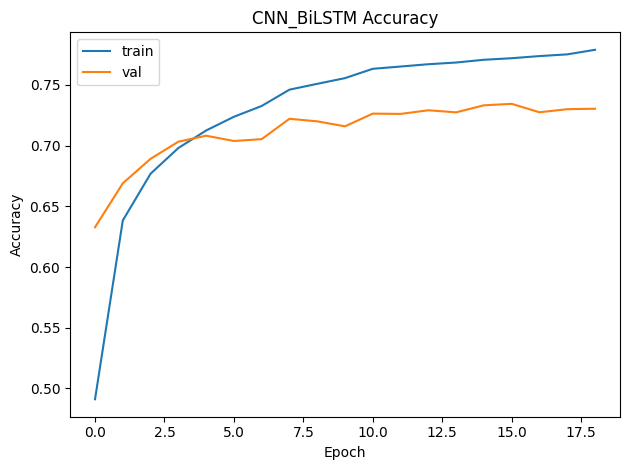

Saved plot: /content/drive/MyDrive/MMCR_Model_Final/plots/CNN_BiLSTM_loss.png


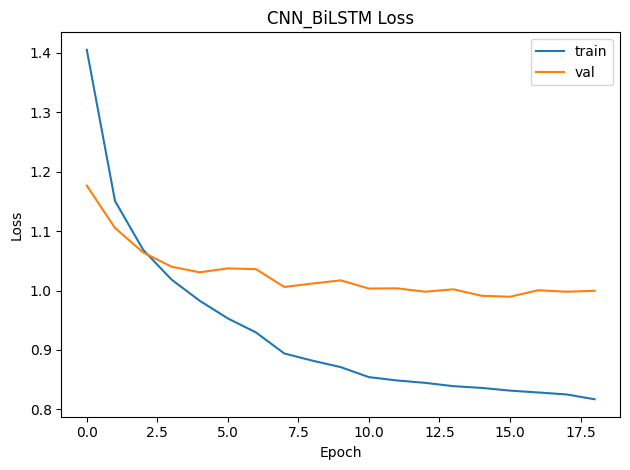

Saved plot: /content/drive/MyDrive/MMCR_Model_Final/plots/best_model_cm_VALID.png


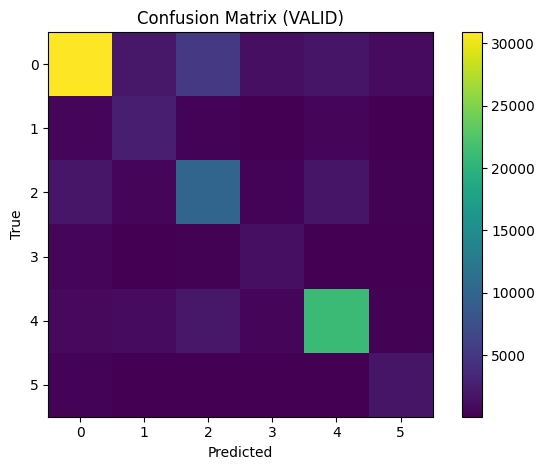

Saved plot: /content/drive/MyDrive/MMCR_Model_Final/plots/best_model_perclassF1_VALID.png


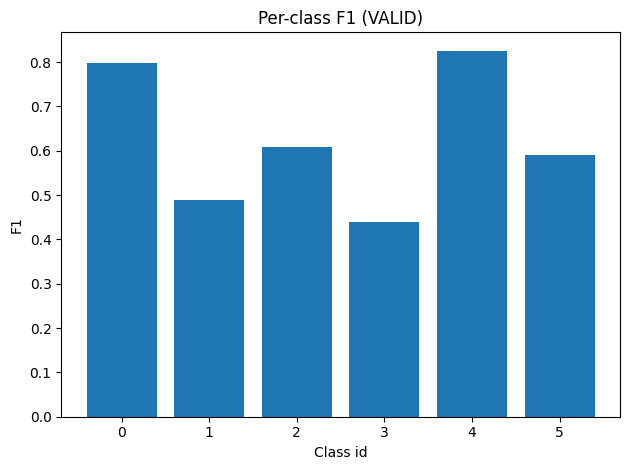

              precision    recall  f1-score   support

           0     0.8770    0.7327    0.7984     42140
           1     0.4092    0.6067    0.4887      4452
           2     0.5573    0.6715    0.6091     15072
           3     0.3692    0.5412    0.4390      2515
           4     0.8306    0.8212    0.8259     25587
           5     0.5221    0.6822    0.5915      2678

    accuracy                         0.7344     92444
   macro avg     0.5943    0.6759    0.6254     92444
weighted avg     0.7654    0.7344    0.7444     92444



In [ ]:

sorted_df = results_df.sort_values("valid_f1", ascending=False)

best_row  = sorted_df.iloc[0]
best_name = best_row["model"]; best_path = best_row["model_path"]
print(f"Best by VALID F1: {best_name} (valid_f1={best_row['valid_f1']:.6f})")
print("Best model path:", best_path)

best_model = tf.keras.models.load_model(best_path)
hist = histories[best_name]

# Plot & save history
plot_history(hist, best_name)

# VALID confusion/per-class
yva_proba = best_model.predict(Xva, batch_size=256, verbose=0)
yva_pred  = yva_proba.argmax(axis=1)
plot_confusion_and_perclass(y_valid_int, yva_pred, name="VALID", prefix="best_model")
print(classification_report(y_valid_int, yva_pred, digits=4))


## Predict on Test — Save TSV with Confidence to Drive

In [ ]:

yte_proba = best_model.predict(Xte, batch_size=256, verbose=1)
yte_pred  = yte_proba.argmax(axis=1)
yte_conf  = yte_proba.max(axis=1)

test_out = test_df.copy()
test_out["pred_label_id"]   = yte_pred
test_out["pred_confidence"] = yte_conf
inv_map = {i:inv_label_map.get(i, i) for i in range(NUM_CLASSES)}
test_out["predicted_label"] = test_out["pred_label_id"].map(inv_map)

if LABEL_COL in test_out.columns:
    test_out["true_label"] = test_out[LABEL_COL].map(inv_label_map)
    test_out["is_correct"] = (test_out["pred_label_id"] == test_out[LABEL_COL])

cols = [c for c in [TEXT_COL, IMAGE_COL, "true_label", "predicted_label", "pred_confidence", "is_correct"] if c in test_out.columns]
pred_path = os.path.join(BASE_DIR, "predictions", "test_predictions_best_model.tsv")
test_out[cols].to_csv(pred_path, sep="\t", index=False)
print("Saved predictions to:", pred_path)


362/362 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Saved predictions to: /content/drive/MyDrive/MMCR_Model_Final/predictions/test_predictions_best_model.tsv


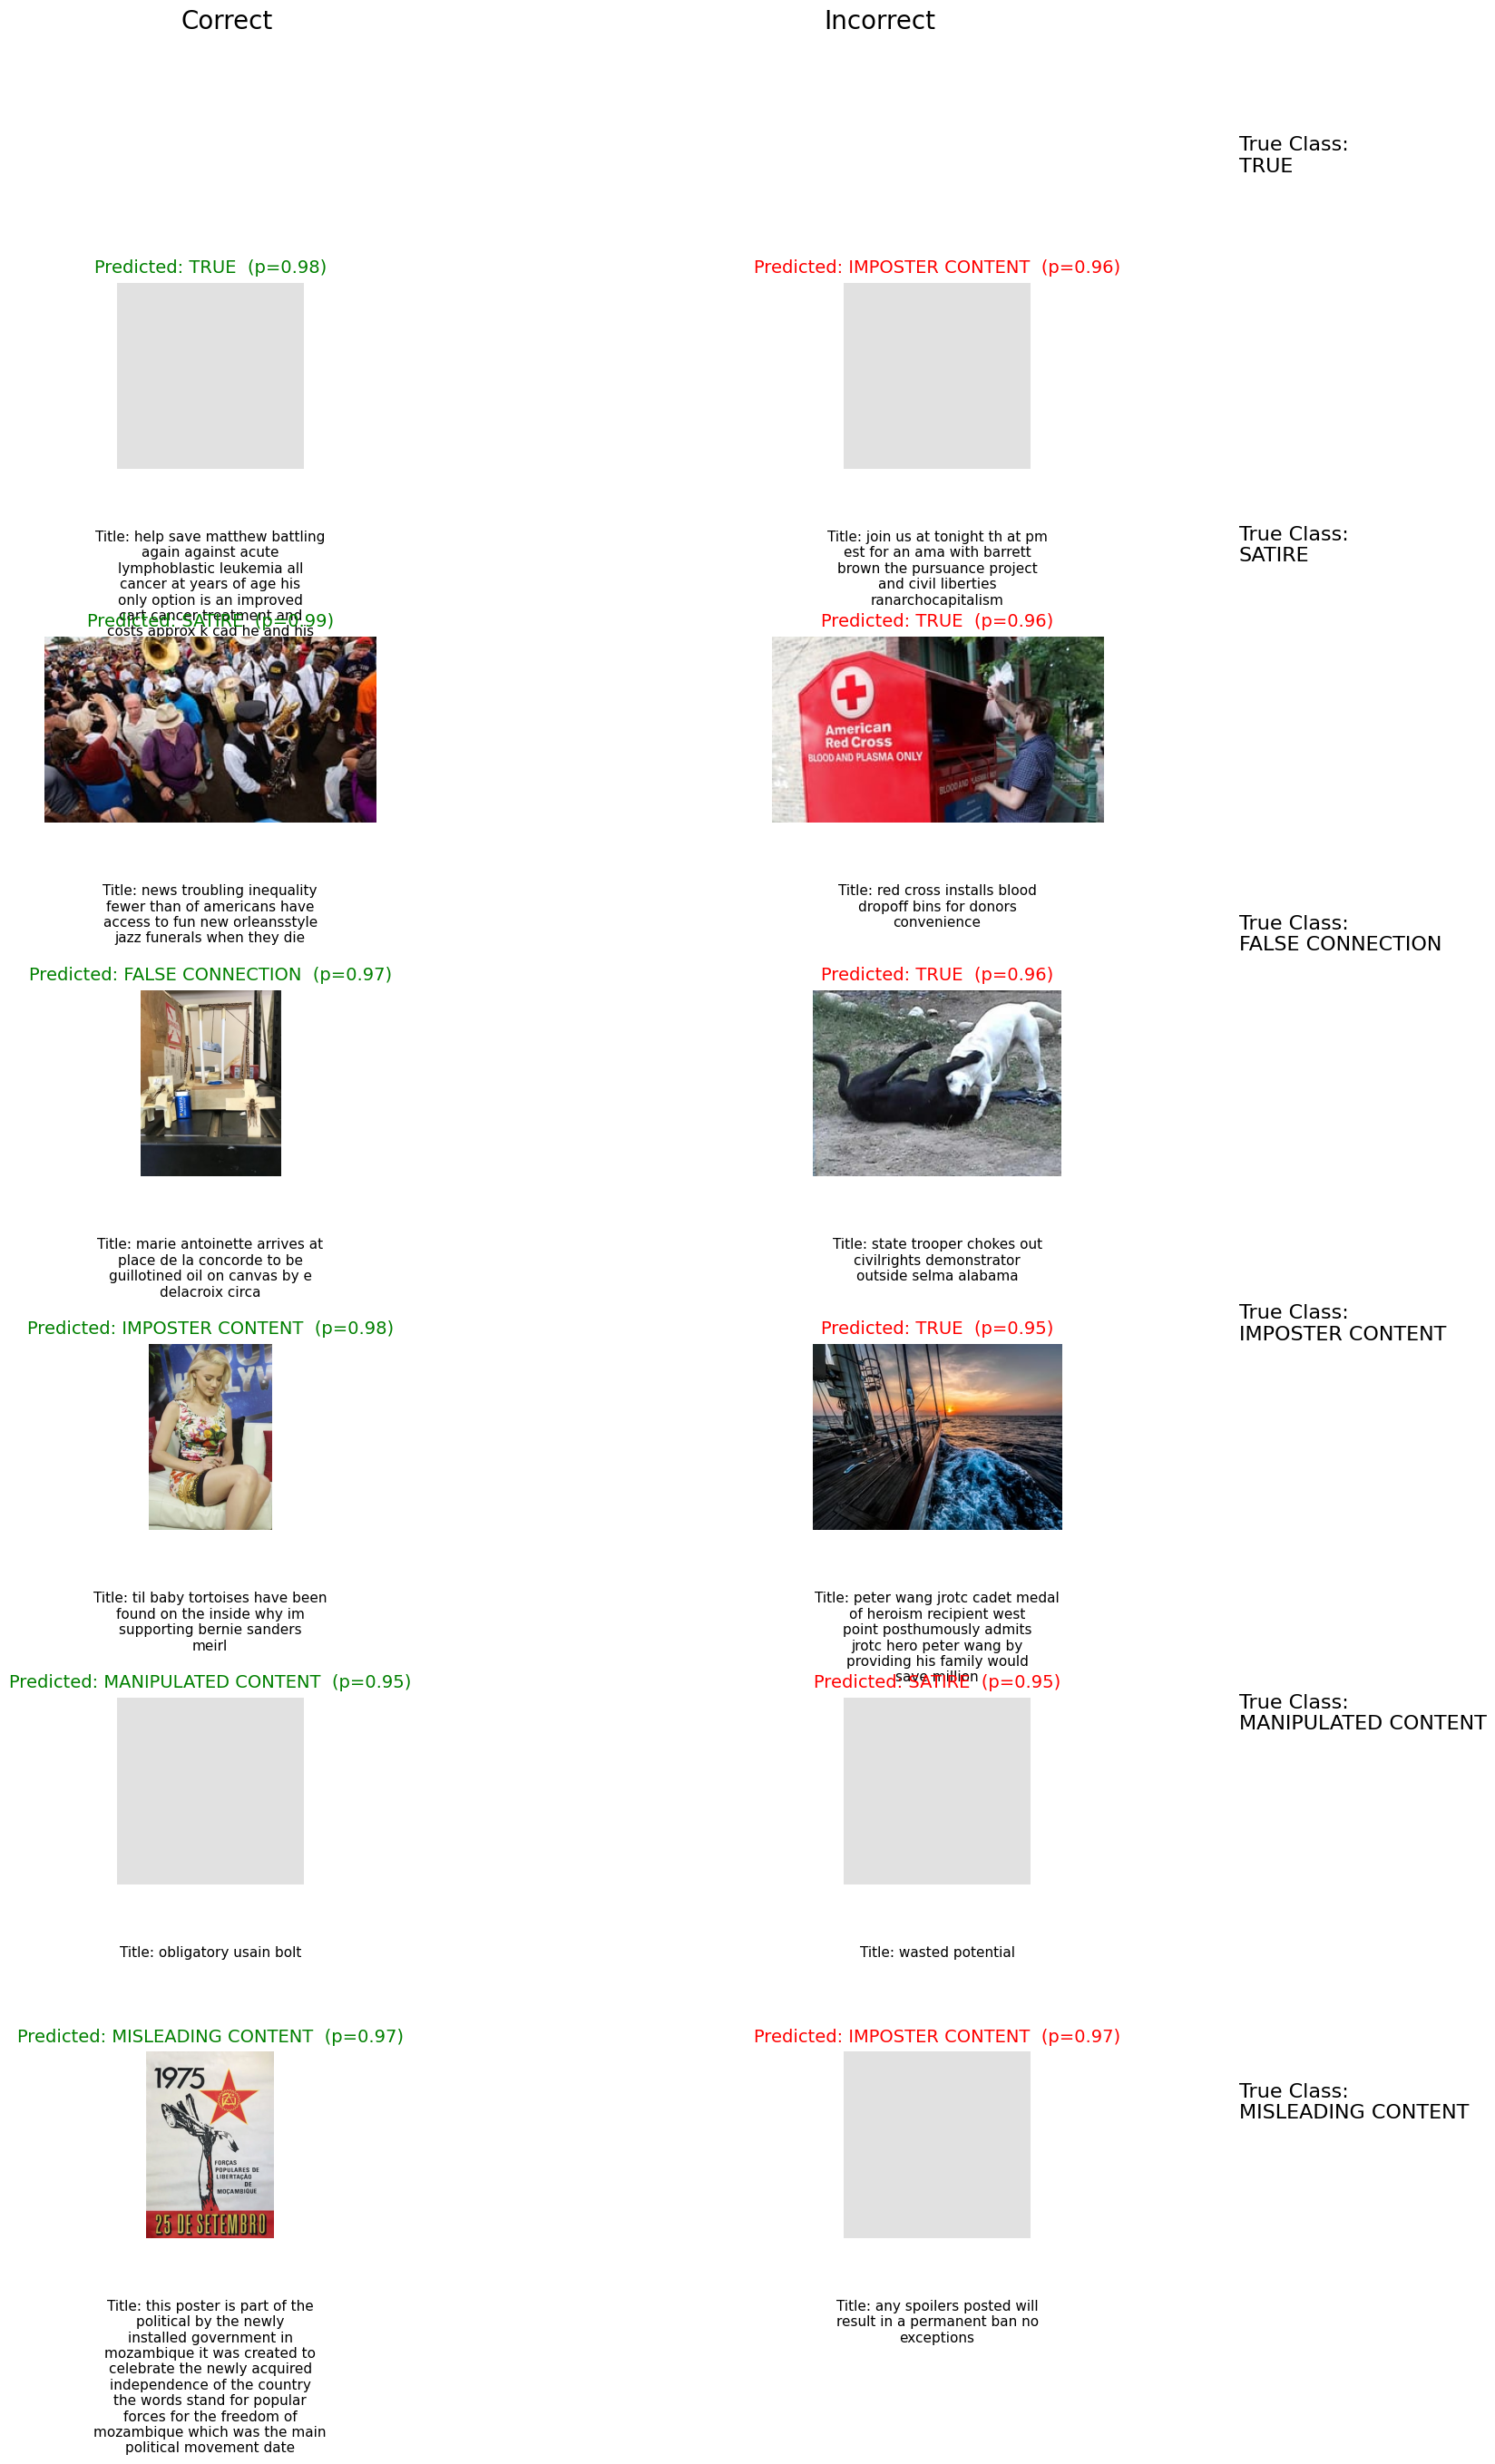

✅ Saved: /content/drive/MyDrive/MMCR_Model_Final/plots/panels_2_per_class.png


In [ ]:
# ===============================================================
# 6×2 Panels (per class): 1 correct + 1 incorrect (max 2 samples/class)
# Saves to: {BASE_DIR}/plots/panels_2_per_class.png
# ===============================================================
import os, io, textwrap, requests
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# ----- Explicit class names for ids 0..5 -----
class_names = [
    'TRUE',
    'SATIRE',
    'FALSE CONNECTION',
    'IMPOSTER CONTENT',
    'MANIPULATED CONTENT',
    'MISLEADING CONTENT'
]
NUM_CLASSES = len(class_names)
inv_label_map = {i: name for i, name in enumerate(class_names)}
name_to_id    = {name: i for i, name in enumerate(class_names)}

# ----- Normalize labels -----
def _to_name(x):
    if x is None or (isinstance(x, float) and np.isnan(x)): return ""
    if isinstance(x, (int, np.integer)): return inv_label_map.get(int(x), str(x))
    if isinstance(x, str) and x.isdigit(): return inv_label_map.get(int(x), x)
    x = str(x).upper()
    return x if x in name_to_id else x

test_out["predicted_label"] = test_out.get("predicted_label", "").map(_to_name)
test_out["true_label"]      = test_out.get("true_label", "").map(_to_name)
test_out["is_correct"]      = test_out["predicted_label"] == test_out["true_label"]

for col in ["pred_confidence", "pred_margin", "conf_entropy"]:
    if col not in test_out.columns:
        test_out[col] = np.nan

# ---- helpers ----
session = requests.Session()
def load_img(row):
    p = row.get("drive_path", "")
    if isinstance(p, str) and p and os.path.exists(p):
        try: return Image.open(p).convert("RGB")
        except Exception: pass
    url = row.get(IMAGE_COL, "")
    if isinstance(url, str) and url:
        try:
            r = session.get(url, timeout=6); r.raise_for_status()
            return Image.open(io.BytesIO(r.content)).convert("RGB")
        except Exception: pass
    return Image.new("RGB", (256,256), (225,225,225))

def wrap_text(s, width=30):
    s = "" if s is None else str(s)
    return "\n".join(textwrap.wrap(s, width=width))

# ---- collect per-class: 1 correct + 1 incorrect ----
samples = {i: {"correct": [], "incorrect": []} for i in range(NUM_CLASSES)}

ordered = test_out.sort_values(
    [c for c in ["pred_confidence", "pred_margin"] if c in test_out.columns],
    ascending=False
)

for _, row in ordered.iterrows():
    tname = row.get("true_label", "")
    if tname not in name_to_id:
        continue
    cid = name_to_id[tname]
    bucket = "correct" if row.get("is_correct", False) else "incorrect"
    if len(samples[cid][bucket]) < 1:
        samples[cid][bucket].append(row)
    # stop when every class has up to 2 samples total (1 per bucket)
    if all(len(v["correct"]) >= 1 and len(v["incorrect"]) >= 1 for v in samples.values()):
        break

# ---- render 6×2 grid ----
fig, axs = plt.subplots(NUM_CLASSES, 2, figsize=(18, 28))
plt.subplots_adjust(hspace=0.9, wspace=0.35)
fig.text(0.30, 0.98, "Correct", fontsize=20, ha="center")
fig.text(0.70, 0.98, "Incorrect", fontsize=20, ha="center")

for cls_idx in range(NUM_CLASSES):
    # True-class callout on the right
    fig.text(0.92, 0.93 - cls_idx*(0.92/NUM_CLASSES),
             f"True Class:\n{class_names[cls_idx]}", fontsize=16, va="center")

    for col_idx, bucket in enumerate(["correct", "incorrect"]):
        ax = axs[cls_idx, col_idx]
        rows = samples[cls_idx][bucket]
        if len(rows) == 0:
            ax.axis("off"); continue

        row = rows[0]  # just one sample per bucket
        img = load_img(row)
        ax.imshow(img)
        p  = row.get("pred_confidence", np.nan)
        pred_name = row.get("predicted_label", "")
        color = "green" if bucket == "correct" else "red"
        tail = "" if np.isnan(p) else f"  (p={p:.2f})"
        ax.set_title(f"Predicted: {pred_name}{tail}", color=color, fontsize=14, pad=8)
        ax.text(0.5, -0.33, f"Title: {wrap_text(row.get(TEXT_COL,''))}",
                transform=ax.transAxes, ha="center", va="top", fontsize=11)
        ax.axis("off")

out_path = os.path.join(BASE_DIR, "plots", "panels_2_per_class.png")
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved:", out_path)
